# Inverse-distance embedding — z = 0 demonstration

Companion to `count_profile_embedding_z0.ipynb`: the same pipeline and figures,
with the profile swapped from cumulative counts to **sorted capped inverse
distances**. Per galaxy: w = min(1/d, CAP) for every neighbour within 2 Mpc/h,
sorted so each galaxy's nearest neighbour occupies the last column (absent
neighbours are 0 = 1/infinity — an exact limit, not a sentinel). Embedding =
PCA of the profile matrix (= classical MDS on squared profile distances).

The cap bounds the small-scale amplification so ~kpc pairs (mergers/deblending)
cannot monopolise the variance: uncapped, one component absorbs 99.4% of the
variance and the leading dimension degrades badly (measured — see the CLAUDE.md
record). CAP = 10 (saturation below 0.1 Mpc/h) was the best of the values swept
so far ({10, 100, uncapped}; a finer sweep is pending).

Reference numbers, RF harness (2026-09-17): Dim 1 alone 0.757 / 0.924 / 0.875
on M200 / satellite / quenched — the best single environment coordinate
measured in this project; dims 1-3: 0.841 / 0.957 / 0.881, tied with the
count-profile embedding at the information ceiling.

**Run on the `py310_clone` kernel** with `../data` holding the TNG catalogs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from sklearn.decomposition import PCA
import illustris_python as il

BASEPATH = '../data'
SNAP     = 99
BOXSIZE  = 75.0
R_MAX    = 2.0        # neighbour search radius, Mpc/h
CAP      = 10.0       # w = min(1/d, CAP): saturates below d = 1/CAP = 0.1 Mpc/h
H        = 0.6774
SSFR_CUT = 1e-11

## Load subhalos and apply the standard cuts

In [2]:
fields = ['SubhaloFlag', 'SubhaloLenType', 'SubhaloMassType', 'SubhaloMass',
          'SubhaloPos', 'SubhaloSFR']
subhalos = il.groupcat.loadSubhalos(BASEPATH, SNAP, fields=fields)
subhalos['original_index'] = np.arange(subhalos['count'])
subhalos['SubhaloPos'] = subhalos['SubhaloPos'] / 1000.0     # kpc/h -> Mpc/h

keep = (subhalos['SubhaloFlag'] > 0) & (subhalos['SubhaloLenType'][:, 4] > 500)
for k in list(subhalos):
    if k != 'count':
        subhalos[k] = subhalos[k][keep]
subhalos['count'] = int(keep.sum())
print(f"after cuts: {subhalos['count']}")
assert subhalos['count'] == 27691

positions = subhalos['SubhaloPos']
N = len(positions)

props = pd.read_csv('progenitor_properties_all.csv')
assert (props['subfind_z0'].to_numpy() == subhalos['original_index']).all()
m200 = props['m200_snap_99'].to_numpy(float)
logm200 = np.where(m200 > 0, np.log10(m200 * 1e10 / H), np.nan)
is_sat = (props['is_central_snap_99'].to_numpy(float) == 0)
mstar = subhalos['SubhaloMassType'][:, 4] * 1e10 / H
sfr = subhalos['SubhaloSFR']
with np.errstate(divide='ignore', invalid='ignore'):
    ssfr = np.where(mstar > 0, sfr / mstar, np.nan)
quenched = np.isfinite(ssfr) & (ssfr < SSFR_CUT)

after cuts: 27691


## Capped inverse-distance profiles

Neighbour distances from a periodic KD-tree (minimum image); each neighbour
contributes w = min(1/d, CAP). Sorting each row ascending right-aligns the
profiles by rank: the last column is every galaxy's nearest neighbour, the
second-to-last its second-nearest, with 0 = "no such neighbour" (= 1/infinity)
padding the left. Same alignment convention as the sorted-distance method,
mirrored to nearest-first.

In [3]:
wrapped = np.asarray(positions, dtype=np.float64) % BOXSIZE
tree = cKDTree(wrapped, boxsize=BOXSIZE)
neighbor_lists = tree.query_ball_point(wrapped, r=R_MAX, workers=-1)

per_gal = []
for i in range(N):
    cand = np.asarray(neighbor_lists[i])
    cand = cand[cand != i]
    if cand.size == 0:
        per_gal.append(np.empty(0))
        continue
    delta = positions[cand] - positions[i]
    delta -= BOXSIZE * np.round(delta / BOXSIZE)
    dist = np.sqrt((delta**2).sum(axis=1))
    dist = dist[dist < R_MAX]
    per_gal.append(np.minimum(1.0 / dist, CAP))

n_nbr = np.array([v.size for v in per_gal])
K = int(n_nbr.max())
print(f'zero-neighbour: {int((n_nbr == 0).sum())} [expected ~1138]; '
      f'max neighbours = K = {K} [expected ~376]')
good = n_nbr > 0

P = np.zeros((N, K))
for i, v in enumerate(per_gal):
    if v.size:
        P[i, K - v.size:] = np.sort(v)     # ascending w -> nearest in last column
print(f'profile matrix: {P.shape}; values in [0, {P.max():g}]; '
      f'at cap: {(P == CAP).sum()} entries')

zero-neighbour: 1138 [expected ~1138]; max neighbours = K = 376 [expected ~376]
profile matrix: (27691, 376); values in [0, 10]; at cap: 12564 entries


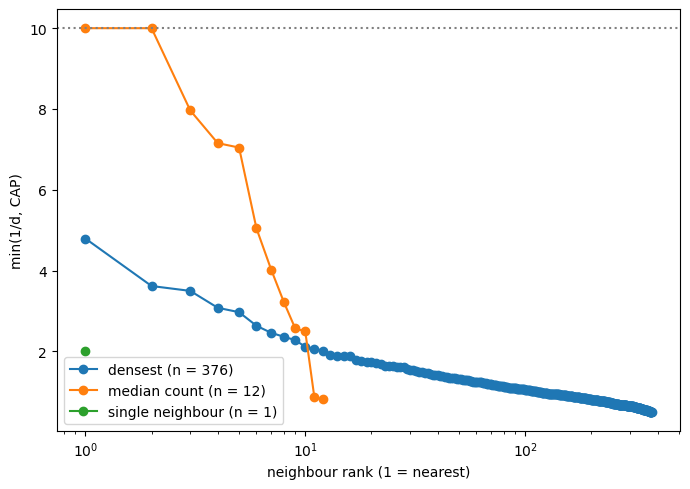

In [4]:
# Example profiles by nearest-neighbour rank (last columns, reversed)
fig, ax = plt.subplots(figsize=(7, 5))
for label, i in [('densest', int(np.argmax(n_nbr))),
                 ('median count', int(np.argsort(n_nbr)[N // 2])),
                 ('single neighbour', int(np.where(n_nbr == 1)[0][0]))]:
    prof = P[i][P[i] > 0][::-1]            # nearest first
    ax.plot(np.arange(1, len(prof) + 1), prof, 'o-',
            label=f'{label} (n = {n_nbr[i]})')
ax.axhline(CAP, ls=':', color='gray')
ax.set_xscale('log')
ax.set_xlabel('neighbour rank (1 = nearest)')
ax.set_ylabel('min(1/d, CAP)')
ax.legend(); plt.tight_layout(); plt.show()

## Embedding: PCA of the capped 1/d profiles

Squared kernel throughout, for comparability with the count-profile notebook
and the O(N K^2) scaling (raw-kernel comparison: see the CLAUDE.md kernel
records).

cumulative variance share: [0.718 0.866 0.927 0.955 0.969 0.977 0.983 0.987 0.989 0.991]


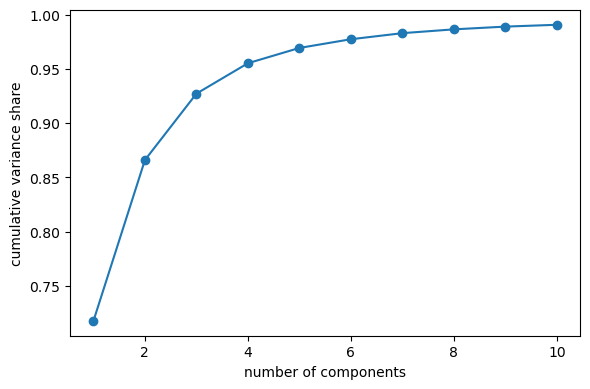

In [5]:
pca = PCA(n_components=10)
X = pca.fit_transform(P)
evr = pca.explained_variance_ratio_
print('cumulative variance share:', np.round(np.cumsum(evr), 3))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(np.arange(1, 11), np.cumsum(evr), 'o-')
ax.set_xlabel('number of components'); ax.set_ylabel('cumulative variance share')
plt.tight_layout(); plt.show()

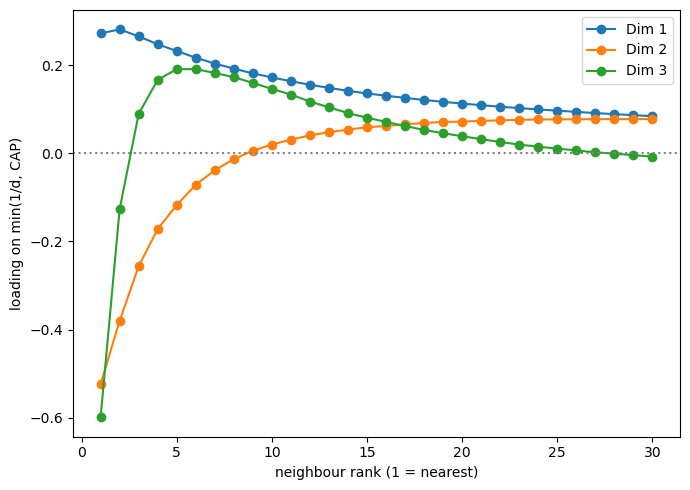

In [6]:
# Loadings by neighbour rank (nearest 30 ranks shown)
fig, ax = plt.subplots(figsize=(7, 5))
ranks = np.arange(1, 31)
for k in range(3):
    ax.plot(ranks, pca.components_[k][::-1][:30], 'o-', label=f'Dim {k+1}')
ax.axhline(0, ls=':', color='gray')
ax.set_xlabel('neighbour rank (1 = nearest)')
ax.set_ylabel('loading on min(1/d, CAP)')
ax.legend(); plt.tight_layout(); plt.show()

## Embedding maps coloured by physical properties

Zero-neighbour galaxies (all-zero profiles) again sit at the coordinate-wise
minimum of the feature space — a single degenerate point at the isolated
extreme of Dim 1, excluded from the maps.

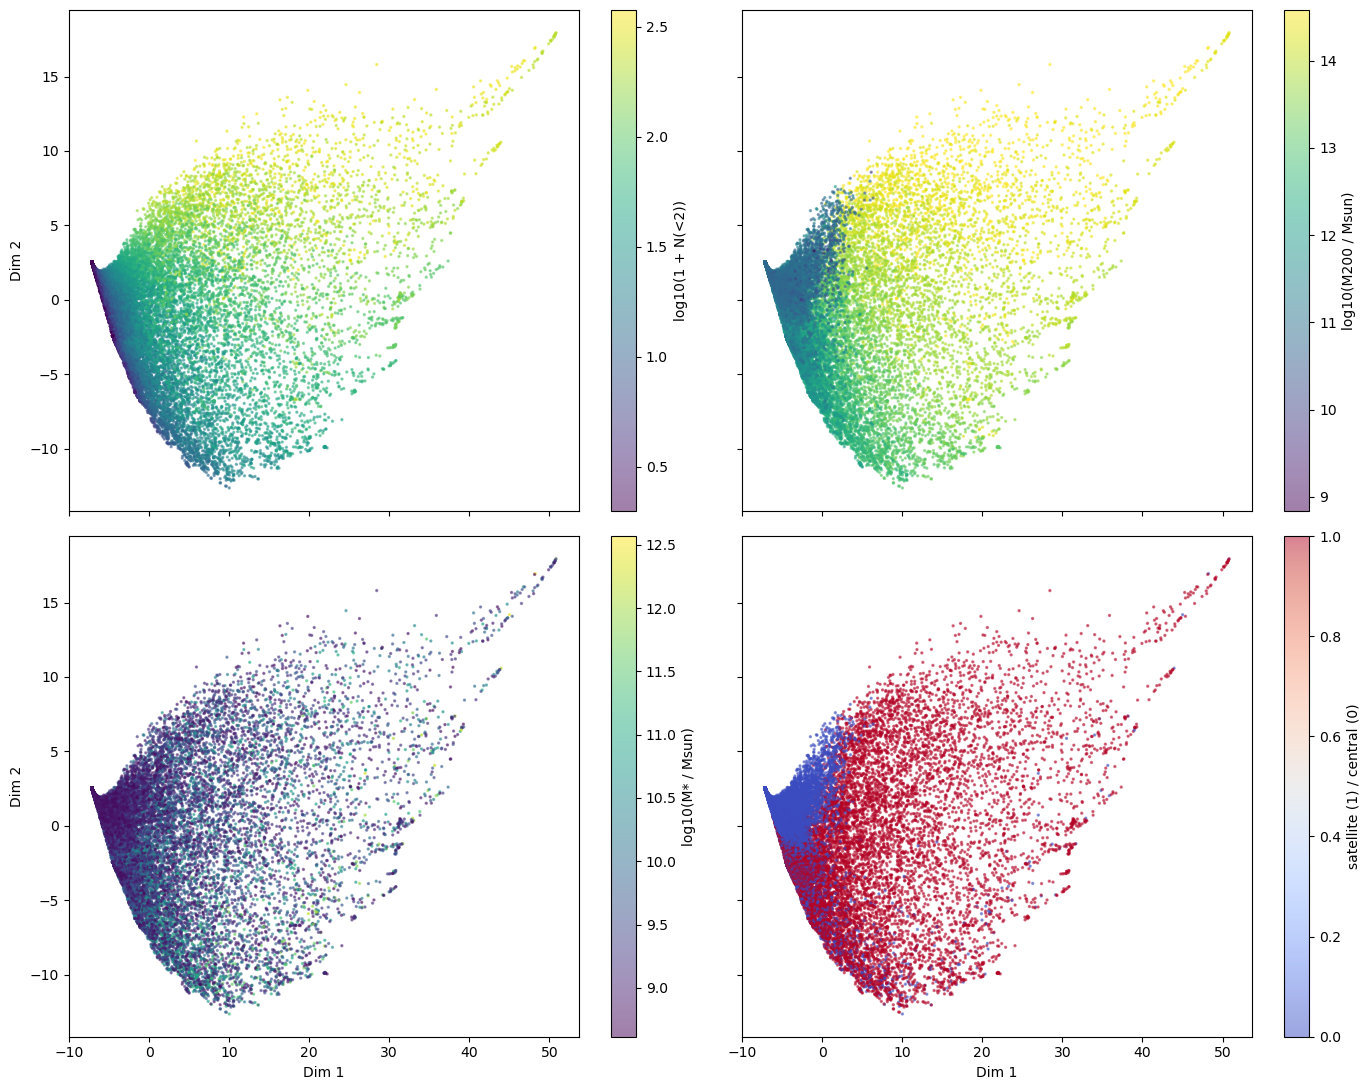

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11), sharex=True, sharey=True)
panels = [
    (np.log10(1 + n_nbr[good]),  'log10(1 + N(<2))',            'viridis'),
    (logm200[good],              'log10(M200 / Msun)',          'viridis'),
    (np.log10(mstar[good]),      'log10(M* / Msun)',            'viridis'),
    (is_sat[good].astype(float), 'satellite (1) / central (0)', 'coolwarm'),
]
for ax, (c, label, cmap) in zip(axes.ravel(), panels):
    ok = np.isfinite(c)
    sc = ax.scatter(X[good, 0][ok], X[good, 1][ok], c=c[ok], s=2, alpha=0.5, cmap=cmap)
    fig.colorbar(sc, ax=ax, label=label)
for ax in axes[-1]:
    ax.set_xlabel('Dim 1')
for ax in axes[:, 0]:
    ax.set_ylabel('Dim 2')
plt.tight_layout(); plt.show()

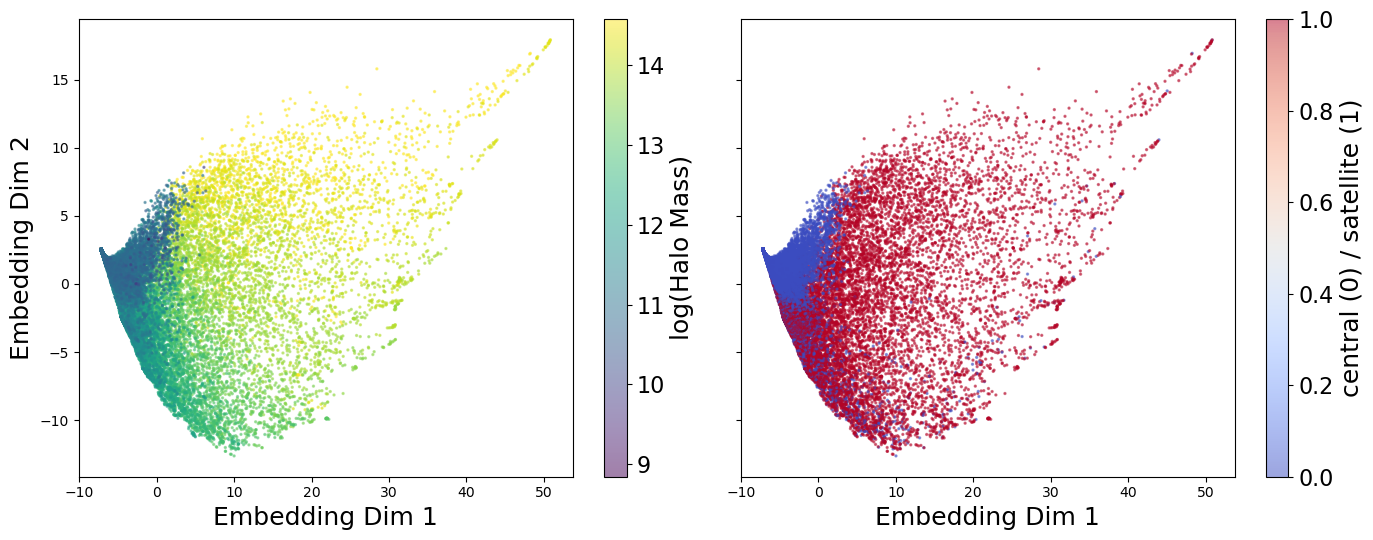

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True, sharey=True)
panels = [
    (logm200[good],              'log(Halo Mass)',          'viridis'),
    (is_sat[good].astype(float), 'central (0) / satellite (1)', 'coolwarm'),
]
for ax, (c, label, cmap) in zip(axes, panels):
    ok = np.isfinite(c)
    sc = ax.scatter(X[good, 0][ok], X[good, 1][ok], c=c[ok], s=2, alpha=0.5, cmap=cmap)
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label(label, fontsize=18)          # <- fontsize goes here, not in fig.colorbar()
    cbar.ax.tick_params(labelsize=16)  
    ax.set_xlabel('Embedding Dim 1', fontsize=18)
axes[0].set_ylabel('Embedding Dim 2', fontsize=18)
plt.tight_layout(); plt.show()


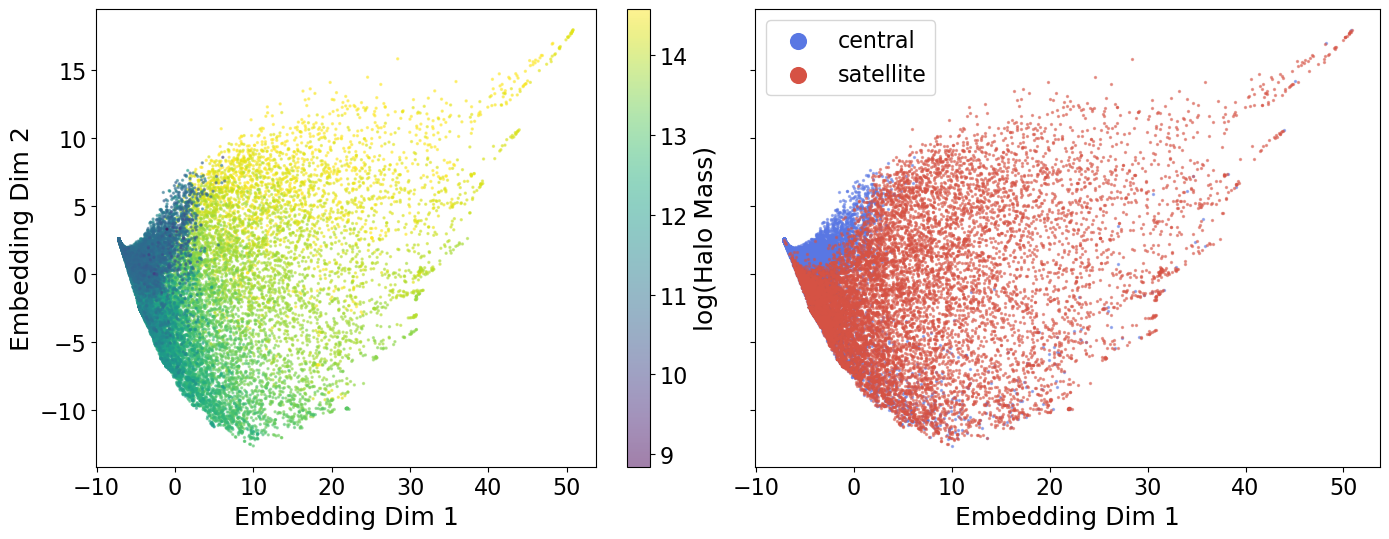

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True, sharey=True)

# left panel: continuous halo-mass colorbar, unchanged
c = logm200[good]
ok = np.isfinite(c)
sc = axes[0].scatter(X[good, 0][ok], X[good, 1][ok], c=c[ok], s=2, alpha=0.5, cmap='viridis')
cbar = fig.colorbar(sc, ax=axes[0])
cbar.set_label('log(Halo Mass)', fontsize=18)
cbar.ax.tick_params(labelsize=16)

# right panel: one scatter per class + legend, no colorbar
cen_color = plt.cm.coolwarm(0.1)
sat_color = plt.cm.coolwarm(0.9)
is_sat_g = is_sat[good]
axes[1].scatter(X[good, 0][~is_sat_g], X[good, 1][~is_sat_g], s=2, alpha=0.5,
                color=cen_color, label='central')
axes[1].scatter(X[good, 0][is_sat_g], X[good, 1][is_sat_g], s=2, alpha=0.5,
                color=sat_color, label='satellite')
leg = axes[1].legend(fontsize=16, markerscale=8, loc='upper left')
for lh in leg.legendHandles:
    lh.set_alpha(1)

for ax in axes:
    ax.set_xlabel('Embedding Dim 1', fontsize=18)
    ax.tick_params(labelsize=16)
axes[0].set_ylabel('Embedding Dim 2', fontsize=18)
plt.tight_layout(); plt.show()


In [43]:
fig.savefig("figures/embedding_z0.pdf", bbox_inches='tight')

## Publication-style comparison figure (as in `illustris_mds_100.ipynb`)

Dim 1 sign flipped for plotting (low = dense, matching the old figure)


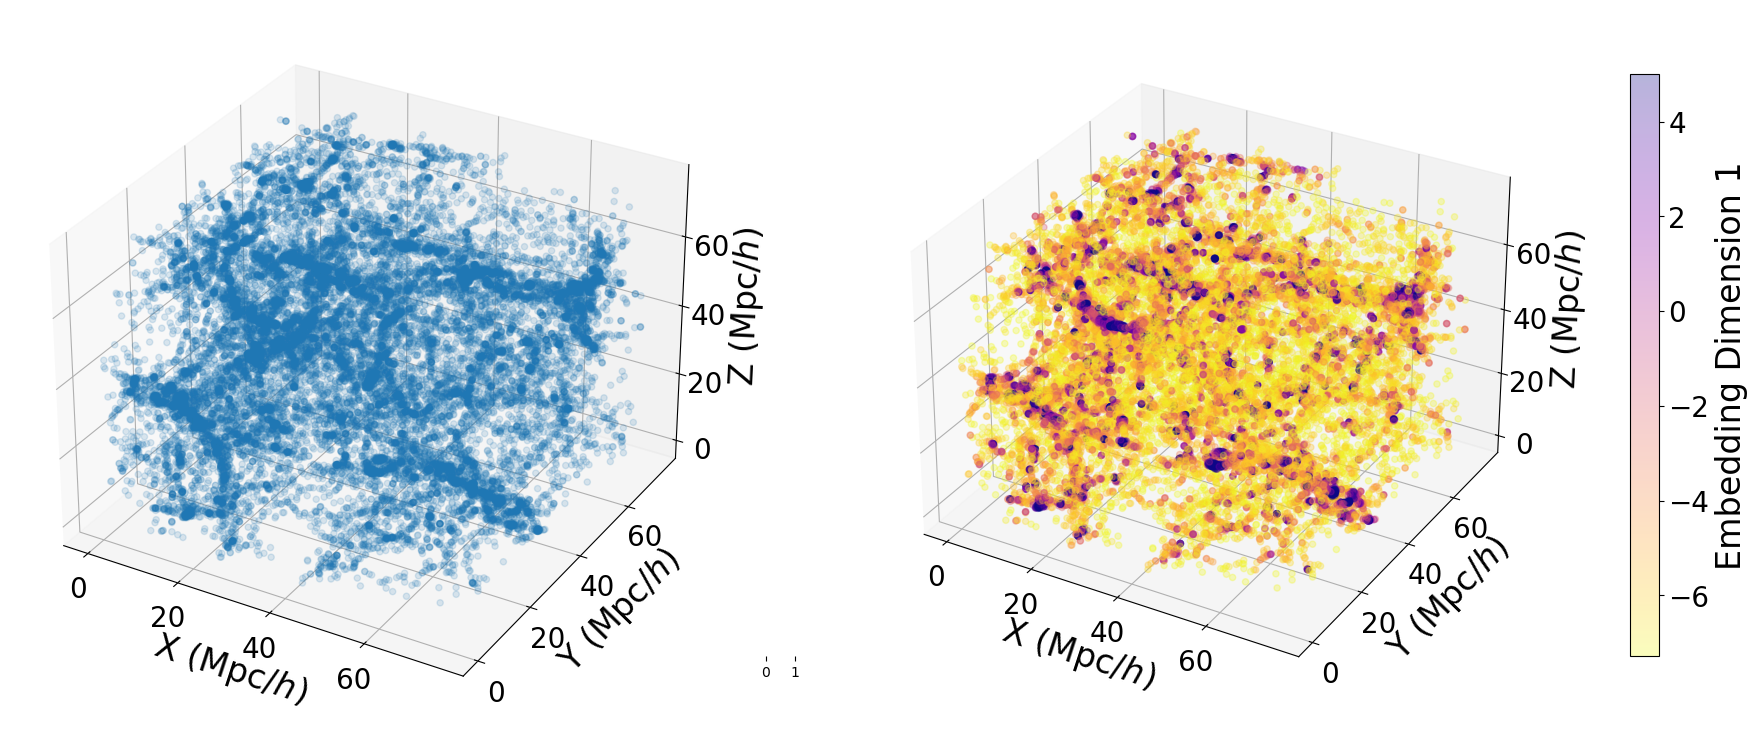

In [56]:
if np.corrcoef(X[good, 0], n_nbr[good])[0, 1] > 0:
    dim1_plot = X[:, 0] # don't flip
    print('Dim 1 sign flipped for plotting (low = dense, matching the old figure)')
else:
    dim1_plot = X[:, 0]
    print('Dim 1 already oriented low = dense')

fig = plt.figure(figsize=(18, 10))
ax1 = plt.subplot(121, projection='3d')
p1 = ax1.scatter(positions[:, 0], positions[:, 1], positions[:, 2], alpha=0.15)
ax1.set_xlabel('X (Mpc/$h$)', fontsize=24, labelpad=10)
ax1.set_ylabel('Y (Mpc/$h$)', fontsize=24, labelpad=10)
ax1.set_zlabel('Z (Mpc/$h$)', fontsize=24, labelpad=8)
ax1.tick_params(axis='both', which='major', labelsize=20)
cbar = fig.colorbar(p1, ax=ax1, shrink=0.6)
cbar.ax.cla(); cbar.outline.set_alpha(0)
for t in cbar.ax.get_yticklines(): t.set_alpha(0)
for l in cbar.ax.get_yticklabels(): l.set_alpha(0)

ax = plt.subplot(122, projection='3d')
p = ax.scatter(positions[:, 0], positions[:, 1], positions[:, 2],
               c=dim1_plot, alpha=0.3, cmap='plasma_r', vmax = 5)
ax.set_xlabel('X (Mpc/$h$)', fontsize=24, labelpad=10)
ax.set_ylabel('Y (Mpc/$h$)', fontsize=24, labelpad=10)
ax.set_zlabel('Z (Mpc/$h$)', fontsize=24, labelpad=8)
ax.tick_params(axis='both', which='major', labelsize=20)
cbar = fig.colorbar(p, ax=ax, shrink=0.6, pad=0.1)
cbar.set_label('Embedding Dimension 1', fontsize=24)
cbar.ax.tick_params(labelsize=20)
plt.tight_layout()
plt.show()
fig.savefig('figures/invdist_embedding_positions_dim1.pdf', bbox_inches='tight')

Dim 1 sign flipped for plotting (low = dense, matching the old figure)


/var/folders/0r/_1bnthz146q2xj0c42f4nl_80000gq/T/ipykernel_31077/252013004.py:29: MatplotlibDeprecationWarning:

Passing parameters norm and vmin/vmax simultaneously is deprecated since 3.3 and will become an error two minor releases later. Please pass vmin/vmax directly to the norm when creating it.



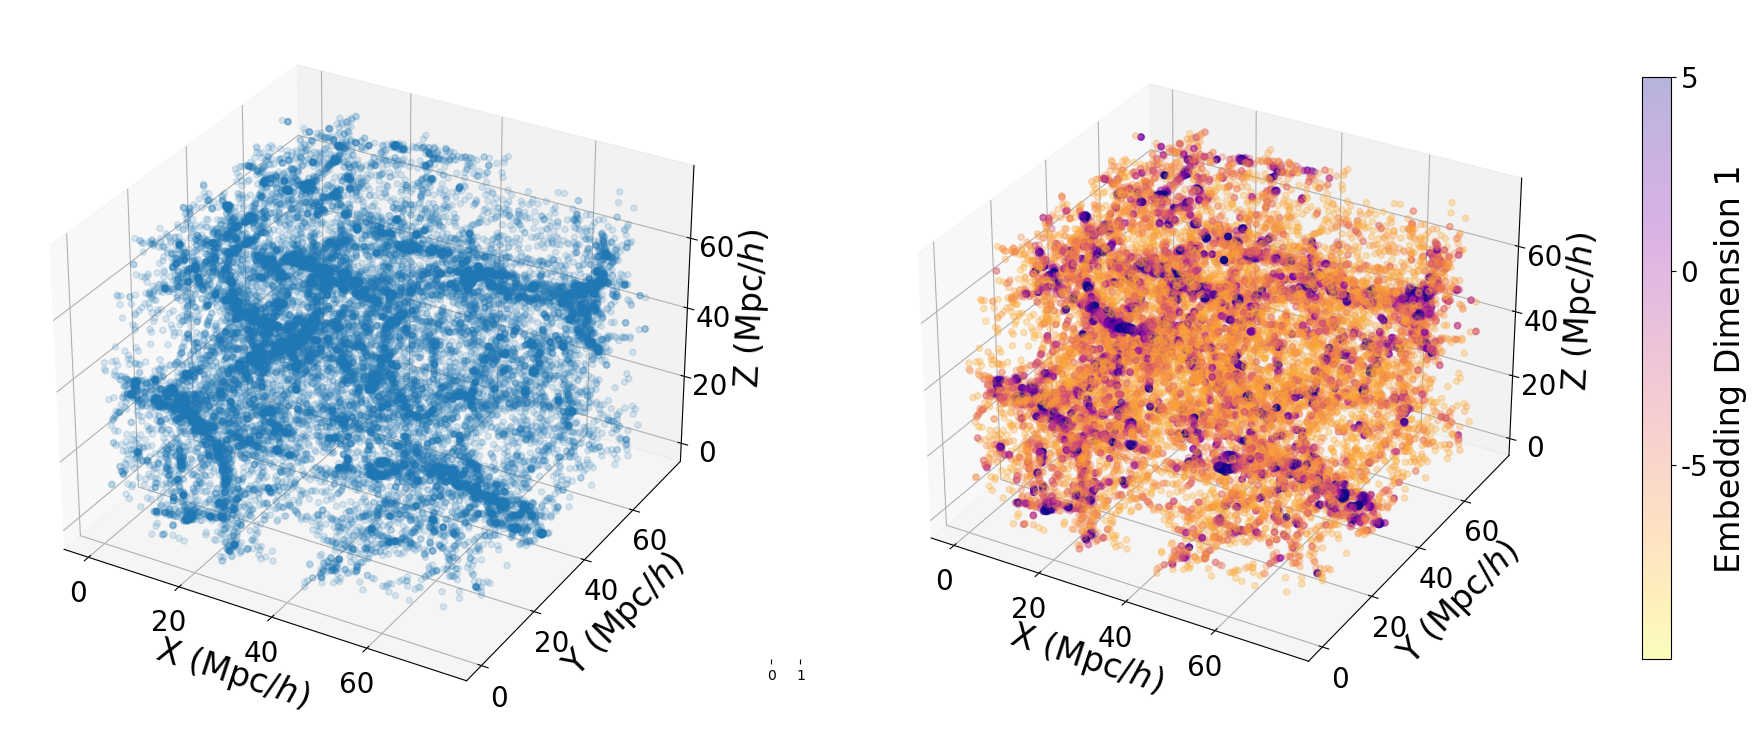

In [73]:
# Symlog-colorbar version of the figure above (both versions kept).
import matplotlib.colors as mcolors

if np.corrcoef(X[good, 0], n_nbr[good])[0, 1] > 0:
    dim1_plot = X[:, 0]
    print('Dim 1 sign flipped for plotting (low = dense, matching the old figure)')
else:
    dim1_plot = X[:, 0]
    print('Dim 1 already oriented low = dense')

fig = plt.figure(figsize=(18, 10))
ax1 = plt.subplot(121, projection='3d')
p1 = ax1.scatter(positions[:, 0], positions[:, 1], positions[:, 2], alpha=0.15)
ax1.set_xlabel('X (Mpc/$h$)', fontsize=24, labelpad=10)
ax1.set_ylabel('Y (Mpc/$h$)', fontsize=24, labelpad=10)
ax1.set_zlabel('Z (Mpc/$h$)', fontsize=24, labelpad=8)
ax1.tick_params(axis='both', which='major', labelsize=20)
cbar = fig.colorbar(p1, ax=ax1, shrink=0.6)
cbar.ax.cla(); cbar.outline.set_alpha(0)
for t in cbar.ax.get_yticklines(): t.set_alpha(0)
for l in cbar.ax.get_yticklabels(): l.set_alpha(0)

ax = plt.subplot(122, projection='3d')
# symlog color scale: linear within |Dim 1| < linthresh, log-compressed beyond,
# so the cluster tail (dim1_plot down to ~-50) keeps color resolution without
# saturating the bulk. Every galaxy gets a valid color (log10 of the negative
# dense-side values was NaN).
norm = mcolors.SymLogNorm(linthresh=10, vmin=-10, vmax=dim1_plot.max())
p = ax.scatter(positions[:, 0], positions[:, 1], positions[:, 2],
               c=dim1_plot, norm=norm, alpha=0.3, cmap='plasma_r', vmax=5)
ax.set_xlabel('X (Mpc/$h$)', fontsize=24, labelpad=10)
ax.set_ylabel('Y (Mpc/$h$)', fontsize=24, labelpad=10)
ax.set_zlabel('Z (Mpc/$h$)', fontsize=24, labelpad=8)
ax.tick_params(axis='both', which='major', labelsize=20)
cbar = fig.colorbar(p, ax=ax, shrink=0.6, pad=0.1)
cbar.set_label('Embedding Dimension 1', fontsize=24)
cbar.set_ticks([-5, 0, 5])
cbar.set_ticklabels(['-5', '0', '5'])
cbar.ax.tick_params(labelsize=20)
plt.tight_layout()
plt.show()
fig.savefig('figures/invdist_embedding_positions_dim1_symlog.pdf', bbox_inches='tight')


## SFR + halo mass vs. Dim 1 (twin-axis figure, as in `illustris_mds_100.ipynb`)

Reproduction of the original's `illustris_sfr_halo_mass.pdf` figure for this embedding: running medians (30 bins) of SFR (left axis, dashed) and parent-halo $M_{200}$ (right axis, log scale) against Dim 1. Uses `dim1_plot` from the cell above (low = dense, the legacy orientation, so the original's axis label applies unchanged). Differences from the original: the sample is the full `_all` selection with the degenerate zero-neighbour galaxies excluded (`good` mask), and halo mass is $M_{200}$ in $M_\odot$ (h-corrected, as everywhere in this notebook) rather than the original's $M_\odot/h$.


(array([15796.,  4913.,  2566.,  1381.,   875.,   486.,   303.,   135.,
           61.,    37.]),
 array([-7.15341558, -1.3550177 ,  4.44338019, 10.24177807, 16.04017596,
        21.83857384, 27.63697173, 33.43536961, 39.2337675 , 45.03216539,
        50.83056327]),
 <BarContainer object of 10 artists>)

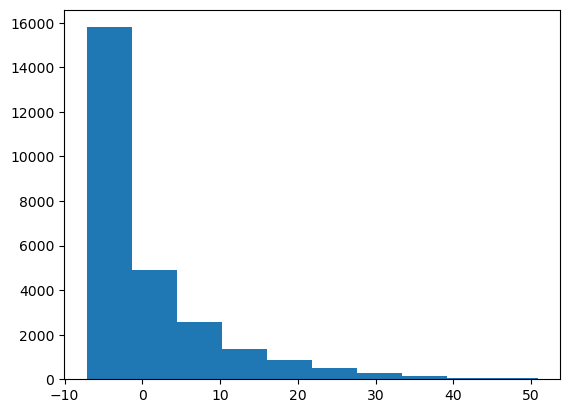

In [62]:
plt.hist(dim1_plot[good])

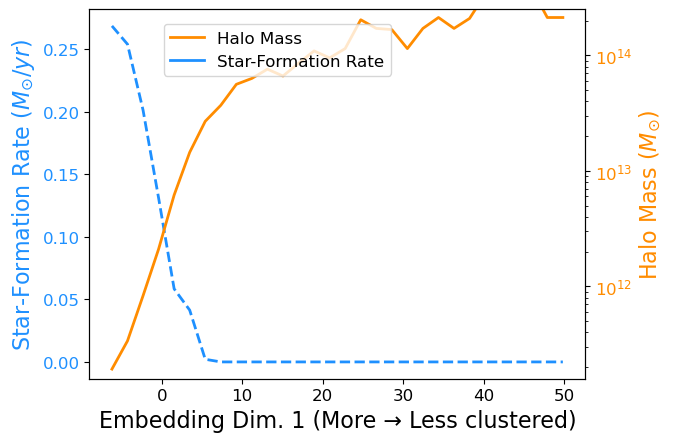

In [79]:
from scipy.stats import binned_statistic

x = dim1_plot[good]
y = sfr[good]
z = logm200[good]

sfr_color = 'dodgerblue'
halo_mass_color = 'darkorange'

ok = np.isfinite(z)                     # m200 = 0 rows have logm200 = NaN
bin_means, bin_edges, _ = binned_statistic(x[ok], np.vstack((y[ok], z[ok])),
                                           statistic='median', bins=30)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

fig, ax1 = plt.subplots()
ax1.plot(bin_centers, bin_means[0, :],
         color=sfr_color, lw=2, label='SFR', linestyle='dashed')
ax1.tick_params(axis='y', labelcolor=sfr_color)

ax2 = ax1.twinx()
ax2.plot(bin_centers, 10**bin_means[1, :], color=halo_mass_color, lw=2, label='Halo Mass')
ax2.plot(0, 10, color=sfr_color, lw=2, label='Star-Formation Rate')  # legend proxy

ax1.set_ylabel('Star-Formation Rate ($M_{\\odot}/yr$)', color=sfr_color, fontsize=16)
ax2.set_ylabel('Halo Mass ($M_{\\odot}$)', color=halo_mass_color, fontsize=16)
ax2.set_ylim(10**11.2, 10**14.4)
ax2.set_yscale('log')
ax2.tick_params(axis='y', labelcolor=halo_mass_color)
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.tick_params(axis='both', which='minor', labelsize=12)
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.tick_params(axis='both', which='minor', labelsize=12)

ax1.set_xlabel('Embedding Dim. 1 (More ' + u'\u2192' + ' Less clustered)', fontsize=16)
plt.legend(loc=(0.15, 0.82), fontsize=12)
plt.show()

fig.savefig('figures/invdist_sfr_halo_mass.pdf', bbox_inches='tight')


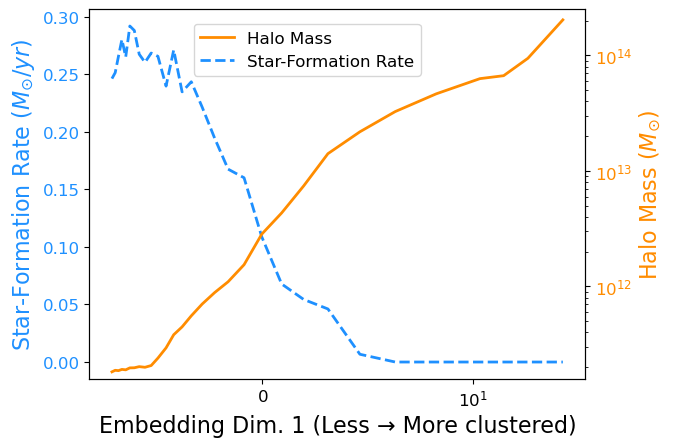

In [67]:
from scipy.stats import binned_statistic

x = dim1_plot[good]
y = sfr[good]
z = logm200[good]

sfr_color = 'dodgerblue'
halo_mass_color = 'darkorange'

ok = np.isfinite(z)                     # m200 = 0 rows have logm200 = NaN

# Equal-count (quantile) bin edges: with a symlog axis, equal-width bins would
# put most bins in the sparse cluster tail; quantile bins give every median
# ~equal statistical weight and follow the axis compression naturally.
n_bins = 30
edges = np.quantile(x[ok], np.linspace(0, 1, n_bins + 1))
edges = np.unique(edges)                # guard against duplicate edges

bin_means, bin_edges, _ = binned_statistic(x[ok], np.vstack((y[ok], z[ok])),
                                           statistic='median', bins=edges)
# plot each median at its bin's median x (better than the midpoint on a nonlinear axis)
bin_x, _, _ = binned_statistic(x[ok], x[ok], statistic='median', bins=edges)

fig, ax1 = plt.subplots()
ax1.plot(bin_x, bin_means[0, :],
         color=sfr_color, lw=2, label='SFR', linestyle='dashed')
ax1.tick_params(axis='y', labelcolor=sfr_color)

ax2 = ax1.twinx()
ax2.plot(bin_x, 10**bin_means[1, :], color=halo_mass_color, lw=2, label='Halo Mass')
ax2.plot([], [], color=sfr_color, lw=2, linestyle='dashed', label='Star-Formation Rate')  # legend proxy

# symlog: linear inside |x| < linthresh, log-compressed beyond -- makes the
# cluster tail (down to -50) legible without clamping the axis
ax1.set_xscale('symlog', linthresh=10)

ax1.set_ylabel('Star-Formation Rate ($M_{\\odot}/yr$)', color=sfr_color, fontsize=16)
ax2.set_ylabel('Halo Mass ($M_{\\odot}$)', color=halo_mass_color, fontsize=16)
ax2.set_ylim(10**11.2, 10**14.4)
ax2.set_yscale('log')
ax2.tick_params(axis='y', labelcolor=halo_mass_color)
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.tick_params(axis='both', which='minor', labelsize=12)
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.tick_params(axis='both', which='minor', labelsize=12)

ax1.set_xlabel('Embedding Dim. 1 (Less ' + u'\u2192' + ' More clustered)', fontsize=16)
plt.legend(loc=(0.21, 0.82), fontsize=12)
plt.show()

fig.savefig('figures/invdist_sfr_halo_mass_symlog.pdf', bbox_inches='tight')


## Interactive 3D view (plotly)

In [78]:
import plotly.express as px
figp = px.scatter_3d(x=positions[:, 0], y=positions[:, 1], z=positions[:, 2],
                     color=[i if i < 5 else 5 for i in X[:, 0]], opacity=0.4, 
                     labels={'x': 'X (Mpc/h)', 'y': 'Y (Mpc/h)', 'z': 'Z (Mpc/h)',
                             'color': 'Embedding Dim 1'})
figp.update_traces(marker=dict(size=3))
figp.update_layout(margin=dict(l=0, r=0, b=0, t=0))
figp.show()

## MLP mini-table

Project-standard MLP harness. The last row (PCA 1-10) is a near-ceiling
proxy: the top 10 components carry ~99% of the profile variance, and in every
comparable test the 10-component row matched the full-input ceiling to ~0.001
at a fraction of the cost of training on all ~376 columns. For reference, the
RF harness measured (2026-09-17): Dim 1 alone 0.757 / 0.924 / 0.875; dims 1-3:
0.841 / 0.957 / 0.881. The `all 10 log-counts` row is the count
representation fed directly (MLP-measured previously at 0.843 / 0.957 /
0.882), for a same-table cross-representation comparison. Takes a few minutes.

In [18]:
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold

MLP_KW = dict(hidden_layer_sizes=(128, 64), alpha=1e-3, max_iter=2000,
              early_stopping=True, n_iter_no_change=30, random_state=0)

# Cross-representation comparison: cumulative log-counts on the standard radius
# grid, from the same KD-tree (see count_profile_embedding_z0.ipynb).
R_GRID = np.arange(0.2, 2.001, 0.2)
counts = np.column_stack(
    [tree.query_ball_point(wrapped, r=r, return_length=True, workers=-1) - 1
     for r in R_GRID])
F_counts = np.log1p(counts)

FEATS = [('n_neighbors',              n_nbr[good].astype(float).reshape(-1, 1)),
         ('PCA dim 1',                X[good][:, :1]),
         ('PCA 1-2',                  X[good][:, :2]),
         ('PCA 1-3',                  X[good][:, :3]),
         ('PCA 1-10',                 X[good][:, :10]),
         ('all 10 log-counts',        F_counts[good])]
TARGETS = [('log M200', logm200[good], 'reg'),
           ('satellite', is_sat[good].astype(float), 'clf'),
           ('quenched', quenched[good].astype(float), 'clf')]

for name, yv, kind in TARGETS:
    m = np.isfinite(yv)
    y = yv[m].astype(int) if kind == 'clf' else yv[m]
    scoring = 'roc_auc' if kind == 'clf' else 'r2'
    cv = (StratifiedKFold(5, shuffle=True, random_state=0) if kind == 'clf'
          else KFold(5, shuffle=True, random_state=0))
    print(f'--- {name}  (N = {int(m.sum())}, {scoring}) ---')
    for lab, Fm in FEATS:
        net = (MLPClassifier(**MLP_KW) if kind == 'clf'
               else MLPRegressor(**MLP_KW))
        est = make_pipeline(StandardScaler(), net)
        s = cross_val_score(est, Fm[m], y, cv=cv, scoring=scoring)
        print(f'{lab:>24}: {s.mean():.4f} +/- {s.std():.4f}')
    print()

--- log M200  (N = 26553, r2) ---
             n_neighbors: 0.5660 +/- 0.0112
               PCA dim 1: 0.7598 +/- 0.0046
                 PCA 1-2: 0.8290 +/- 0.0058
                 PCA 1-3: 0.8418 +/- 0.0048
                PCA 1-10: 0.8378 +/- 0.0050
       all 10 log-counts: 0.8427 +/- 0.0049

--- satellite  (N = 26553, roc_auc) ---
             n_neighbors: 0.8259 +/- 0.0084
               PCA dim 1: 0.9269 +/- 0.0033
                 PCA 1-2: 0.9541 +/- 0.0035
                 PCA 1-3: 0.9589 +/- 0.0020
                PCA 1-10: 0.9563 +/- 0.0037
       all 10 log-counts: 0.9572 +/- 0.0021

--- quenched  (N = 26553, roc_auc) ---
             n_neighbors: 0.8373 +/- 0.0043
               PCA dim 1: 0.8796 +/- 0.0048
                 PCA 1-2: 0.8826 +/- 0.0043
                 PCA 1-3: 0.8826 +/- 0.0050
                PCA 1-10: 0.8820 +/- 0.0058
       all 10 log-counts: 0.8824 +/- 0.0041



## Notes

- The cap is this representation's one hyperparameter: it trades small-scale
  sensitivity against artifact amplification. Its value only matters for the
  low-dimensional organisation (dims 1-2); by 3 dims all tested caps reach the
  ceiling.
- Out-of-sample projection is the same exact linear algebra as the count
  notebook: `(P_new - pca.mean_) @ pca.components_.T`. One cross-snapshot
  caveat the counts do not have: K (the profile width) is set by the densest
  galaxy, so profiles from another snapshot must be left-padded with zeros to
  the wider K before projecting -- never truncated.